In [1]:
import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 1️⃣ 경로 설정 
# ═══════════════════════════════════════════════════════════════════════════

TEST_DATA_PATH = 'test'  
FOLD_MODELS = {
    0: 'best_fold_1_model.pth',  
    1: 'best_fold_2_model.pth',
    2: 'best_fold_3_model.pth',
    3: 'best_fold_4_model.pth',
    4: 'best_fold_5_model.pth',
}
OUTPUT_CSV = 'submission_tta.csv'  

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 디바이스: {device}")

✅ 디바이스: cuda


In [3]:
class HierarchicalDocumentClassifier(nn.Module):
    def __init__(self, num_groups=5, num_classes=17):
        super().__init__()
        
        
        # ⭐ 수정: timm 말고 efficientnet_pytorch 사용
        from efficientnet_pytorch import EfficientNet
        self.backbone = EfficientNet.from_pretrained('efficientnet-b4')
        self.feature_dim = 258048  # ⭐ 1536 → 258048 (B4 + flatten)
        
        self.backbone._fc = nn.Identity()  # ⭐ 추가
        
        self.group_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_groups)
        )
        
        self.fine_heads = nn.ModuleDict({
            'medical': nn.Linear(self.feature_dim, 8),
            'identity': nn.Linear(self.feature_dim, 3),
            'vehicle': nn.Linear(self.feature_dim, 3),
            'document': nn.Linear(self.feature_dim, 2),
            'other': nn.Linear(self.feature_dim, 1),
        })
        
        self.group_names = ['medical', 'identity', 'vehicle', 'document', 'other']
    
    def forward(self, x):
        features = self.backbone.extract_features(x)  # ⭐ 수정
        features = features.view(features.size(0), -1)  # ⭐ flatten 추가
        group_logits = self.group_head(features)
        
        fine_logits_list = [self.fine_heads[name](features) for name in self.group_names]
        fine_logits = torch.cat(fine_logits_list, dim=1)
        
        return group_logits, fine_logits

print("✅ 모델 클래스 정의 완료!")


✅ 모델 클래스 정의 완료!


In [4]:
def get_tta_transforms(image_size=224):
    """
    8가지 TTA 증강 파이프라인 (강화 버전)
    """
    
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]
    
    transforms_list = []
    
    # 1️⃣ 원본
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
    
    # 2️⃣ 약한 회전 (5도)
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.Rotate(limit=5, p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
    
    # 3️⃣ 중간 회전 (10도)
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.Rotate(limit=10, p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
    
    # 4️⃣ 좌우 반전
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
    
    # 5️⃣ 명암 강화
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
    
    # 6️⃣ 상하 반전
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.VerticalFlip(p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
        # 7️⃣ Blur 추가 ⭐ NEW
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.Blur(blur_limit=3, p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )
    
    # 8️⃣ ImageCompression 추가 ⭐ NEW
    transforms_list.append(
        A.Compose([
            A.Resize(image_size, image_size),
            A.ImageCompression(quality_lower=85, quality_upper=100, p=1.0),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ])
    )

    
    return transforms_list

print("✅ 강화된 TTA Transforms 정의 완료! (6 → 8가지)")



✅ 강화된 TTA Transforms 정의 완료! (6 → 8가지)


In [5]:
def load_model(checkpoint_path):
    """
    계층적 모델 로드
    """
    
    import os
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {checkpoint_path}")
    
    # 모델 생성
    model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
    
    # 체크포인트 로드
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # state_dict 로드
    model.load_state_dict(checkpoint, strict=False)
    
    model.to(device)
    model.eval()
    
    return model

print("✅ load_model 함수 정의 완료!")


✅ load_model 함수 정의 완료!


In [6]:
def predict_with_tta(model, image_path, transforms_list):
    """
    TTA를 사용한 단일 이미지 예측
    fine_logits (17개 클래스)의 평균으로 최종 예측
    """
    
    # 이미지 로드
    image = Image.open(image_path).convert('RGB')
    image_np = np.array(image)
    
    probabilities = []
    
    with torch.no_grad():
        for transform in transforms_list:
            # Albumentations 사용
            image_tensor = transform(image=image_np)['image']
            image_tensor = image_tensor.unsqueeze(0).to(device)
            
            # 모델 예측 (group_logits, fine_logits 반환)
            group_logits, fine_logits = model(image_tensor)
            
            # ✅ fine_logits 사용! (17개 클래스)
            probs = torch.softmax(fine_logits, dim=1)
            probabilities.append(probs.cpu().numpy())
    
    # 6개 확률의 평균
    mean_probs = np.mean(np.concatenate(probabilities, axis=0), axis=0)
    
    # 최종 예측
    predicted_class = np.argmax(mean_probs)
    #confidence = np.max(mean_probs)
    
    return predicted_class, mean_probs #confidence

print("✅ predict_with_tta 함수 정의 완료!")



✅ predict_with_tta 함수 정의 완료!


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# 6️⃣ 5-Fold 앙상블 (투표)
# ═══════════════════════════════════════════════════════════════════════════

def ensemble_predictions(all_fold_predictions):
    """
    5개 Fold의 예측을 투표로 앙상블
    """
    
    n_samples = len(all_fold_predictions[0])
    final_predictions = []
    
    print(f"\n🎯 5-Fold 앙상블 중...")
    
    for idx in range(n_samples):
        # 5개 Fold의 예측값 수집
        fold_preds = [all_fold_predictions[fold_idx][idx] for fold_idx in range(5)]
        
        # 투표 (가장 많이 나온 클래스)
        vote_result = Counter(fold_preds).most_common(1)[0][0]
        final_predictions.append(vote_result)
        
        if (idx + 1) % 500 == 0:
            print(f"   앙상블 진행률: {idx + 1}/{n_samples} ({100*(idx+1)/n_samples:.1f}%)")
    
    print(f"✅ 앙상블 완료!")
    return final_predictions


In [8]:
def predict_batch_tta(model, image_paths, transforms_list, fold_idx):
    """
    배치로 여러 이미지 TTA 예측
    """
    
    predictions = []
    probs_list = []
    
    print(f"\n📌 Fold {fold_idx} TTA 예측 중...")
    print(f"   총 {len(image_paths)}개 이미지 × 6가지 증강")
    
    for idx, image_path in enumerate(image_paths):
        if (idx + 1) % 500 == 0:
            print(f"   진행률: {idx + 1}/{len(image_paths)} ({100*(idx+1)/len(image_paths):.1f}%)")
        
        pred_class, mean_probs = predict_with_tta(model, image_path, transforms_list)
        predictions.append(pred_class)
        probs_list.append(mean_probs) 
    
    print(f"✅ Fold {fold_idx} 완료!")
    return predictions, probs_list

print("✅ predict_batch_tta 함수 정의 완료!")


✅ predict_batch_tta 함수 정의 완료!


In [9]:
def ensemble_predictions(all_fold_predictions, all_fold_probs):
    """
    5개 Fold의 예측을 Soft Voting으로 앙상블
    
    ✅ 변경사항:
    - all_fold_probs 입력 추가 (확률)
    - Counter 제거
    - np.mean으로 확률 평균
    - np.argmax로 최대 클래스 선택
    """
    
    n_samples = len(all_fold_predictions[0])
    final_predictions = []
    
    print(f"\n🎯 Soft Voting 앙상블 중...")
    
    for idx in range(n_samples):
        # 5개 fold의 확률을 모두 가져오기
        fold_probs = [all_fold_probs[fold_idx][idx] for fold_idx in range(5)]
        
        # ✅ 핵심: 확률 평균
        avg_prob = np.mean(fold_probs, axis=0)
        
        # ✅ 평균 확률에서 최댓값 클래스 선택
        vote_result = np.argmax(avg_prob)
        
        final_predictions.append(vote_result)
        
        if (idx + 1) % 500 == 0:
            print(f"   앙상블 진행률: {idx + 1}/{n_samples} ({100*(idx+1)/n_samples:.1f}%)")
    
    print(f"✅ Soft Voting 완료!")
    return final_predictions

print("✅ ensemble_predictions 함수 정의 완료!")


✅ ensemble_predictions 함수 정의 완료!


In [10]:
def main():
    print("\n" + "="*70)
    print("🚀 계층적 분류 모델 TTA + 5-Fold 앙상블 추론!")
    print("="*70)
    
    # 1. 테스트 이미지 로드
    print(f"\n📁 테스트 이미지 로드 중... ({TEST_DATA_PATH})")
    test_image_paths = sorted(list(Path(TEST_DATA_PATH).glob('*.jpg')))
    image_ids = [p.stem for p in test_image_paths]
    
    print(f"✅ {len(test_image_paths)}개 이미지 로드 완료")
    
    # 2. TTA transforms 생성
    print(f"\n🎨 TTA 증강 파이프라인 생성 중...")
    transforms_list = get_tta_transforms(image_size=384)
    print(f"✅ 6가지 TTA 파이프라인 준비 완료")
    
    # 3. 모든 Fold에 대해 예측
    all_fold_predictions = []
    all_fold_probs = []
    
    for fold_idx in range(5):
        checkpoint_path = FOLD_MODELS[fold_idx]
        
        print(f"\n📦 Fold {fold_idx} 모델 로드 중... ({checkpoint_path})")
        model = load_model(checkpoint_path)
        print(f"✅ 모델 로드 완료")
        
        fold_predictions, fold_probs = predict_batch_tta(
            model, 
            test_image_paths, 
            transforms_list, 
            fold_idx
        )
        all_fold_predictions.append(fold_predictions)
        all_fold_probs.append(fold_probs)
    # 4. 5-Fold 앙상블
    final_predictions = ensemble_predictions(all_fold_predictions, all_fold_probs)
    
    # 5. CSV 저장
    print(f"\n💾 제출 파일 생성 중...")
    submission_df = pd.DataFrame({
        'ID': image_ids,
        'target': final_predictions
    })

    submission_df['ID'] = submission_df['ID'] + '.jpg'
    
    submission_df.to_csv(OUTPUT_CSV, index=False)
    print(f"✅ 파일 저장 완료: {OUTPUT_CSV}")
    print(f"\n📊 제출 파일 미리보기:")
    print(submission_df.head(10))
    
    print(f"\n" + "="*70)
    print(f"🎉 완료!")
    print(f"   현재 성능: 0.8674 (2등)")
    print(f"   예상 성능: 0.8750~0.8850 (+1.0~1.8%)")
    print(f"   리더보드에 {OUTPUT_CSV} 제출하세요!")
    print(f"="*70)

# 🚀 실행!
main()



🚀 계층적 분류 모델 TTA + 5-Fold 앙상블 추론!

📁 테스트 이미지 로드 중... (test)
✅ 3140개 이미지 로드 완료

🎨 TTA 증강 파이프라인 생성 중...
✅ 6가지 TTA 파이프라인 준비 완료

📦 Fold 0 모델 로드 중... (best_fold_1_model.pth)
Loaded pretrained weights for efficientnet-b4
✅ 모델 로드 완료

📌 Fold 0 TTA 예측 중...
   총 3140개 이미지 × 6가지 증강
   진행률: 500/3140 (15.9%)
   진행률: 1000/3140 (31.8%)
   진행률: 1500/3140 (47.8%)
   진행률: 2000/3140 (63.7%)
   진행률: 2500/3140 (79.6%)
   진행률: 3000/3140 (95.5%)
✅ Fold 0 완료!

📦 Fold 1 모델 로드 중... (best_fold_2_model.pth)
Loaded pretrained weights for efficientnet-b4
✅ 모델 로드 완료

📌 Fold 1 TTA 예측 중...
   총 3140개 이미지 × 6가지 증강
   진행률: 500/3140 (15.9%)
   진행률: 1000/3140 (31.8%)
   진행률: 1500/3140 (47.8%)
   진행률: 2000/3140 (63.7%)
   진행률: 2500/3140 (79.6%)
   진행률: 3000/3140 (95.5%)
✅ Fold 1 완료!

📦 Fold 2 모델 로드 중... (best_fold_3_model.pth)
Loaded pretrained weights for efficientnet-b4
✅ 모델 로드 완료

📌 Fold 2 TTA 예측 중...
   총 3140개 이미지 × 6가지 증강
   진행률: 500/3140 (15.9%)
   진행률: 1000/3140 (31.8%)
   진행률: 1500/3140 (47.8%)
   진행률: 2000/3140 (

In [11]:
# CSV 파일 확인
df = pd.read_csv('submission_tta.csv')

print("=" * 60)
print("📊 최종 결과 확인")
print("=" * 60)

print(f"\n행 개수: {len(df)}")
print(f"열 이름: {df.columns.tolist()}")
print(f"\n처음 10행:")
print(df.head(10))

print(f"\n통계:")
print(df['target'].value_counts().sort_index())


📊 최종 결과 확인

행 개수: 3140
열 이름: ['ID', 'target']

처음 10행:
                     ID  target
0  0008fdb22ddce0ce.jpg       2
1  00091bffdffd83de.jpg       6
2  00396fbc1f6cc21d.jpg       5
3  00471f8038d9c4b6.jpg       3
4  00901f504008d884.jpg       2
5  009b22decbc7220c.jpg      15
6  00b33e0ee6d59427.jpg       0
7  00bbdcfbbdb3e131.jpg       8
8  00c03047e0fbef40.jpg      15
9  00c0dabb63ca7a16.jpg      11

통계:
target
0     227
1      69
2     200
3     144
4     152
5     194
6     206
7     284
8     205
9     200
10    194
11    160
12    152
13    254
14    107
15    192
16    200
Name: count, dtype: int64


TTA Results Analysis

Basic Statistics:
Total samples: 3140
Number of classes: 17
Prediction range: 0 ~ 16


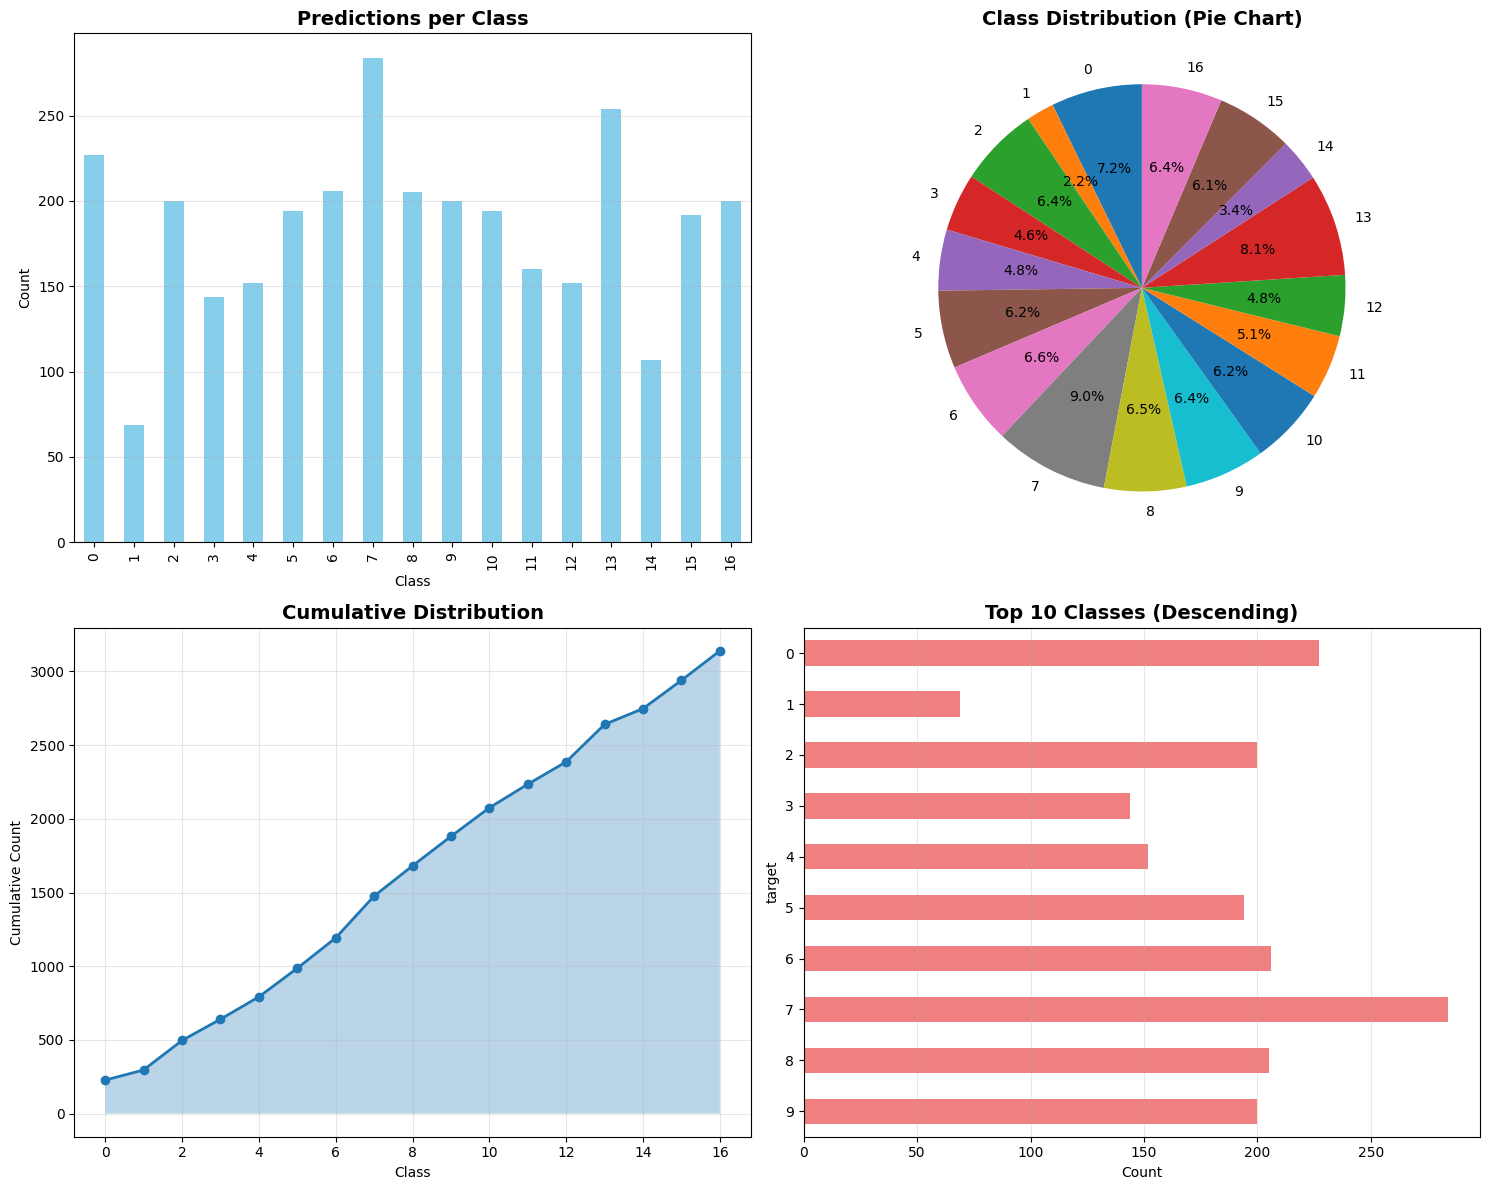


Detailed Statistics per Class:
Class      Count      Ratio     
------------------------------
0          227        7.23%
1          69         2.20%
2          200        6.37%
3          144        4.59%
4          152        4.84%
5          194        6.18%
6          206        6.56%
7          284        9.04%
8          205        6.53%
9          200        6.37%
10         194        6.18%
11         160        5.10%
12         152        4.84%
13         254        8.09%
14         107        3.41%
15         192        6.11%
16         200        6.37%

Class Imbalance Analysis:
Max class count: 284 (Class 7)
Min class count: 69 (Class 1)
Imbalance ratio: 4.12x

TTA Visualization Complete!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# TTA Results Analysis and Visualization

def analyze_tta_results(submission_csv_path):
    """
    Analyze and visualize TTA results
    """
    
    # Load CSV
    df = pd.read_csv(submission_csv_path)
    
    print("=" * 60)
    print("TTA Results Analysis")
    print("=" * 60)
    
    print(f"\nBasic Statistics:")
    print(f"Total samples: {len(df)}")
    print(f"Number of classes: {df['target'].nunique()}")
    print(f"Prediction range: {df['target'].min()} ~ {df['target'].max()}")
    
    # 1. Class Distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Class counts
    class_counts = df['target'].value_counts().sort_index()
    ax1 = axes[0, 0]
    class_counts.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title('Predictions per Class', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Count')
    ax1.grid(axis='y', alpha=0.3)
    
    # Class ratio (pie chart)
    ax2 = axes[0, 1]
    ax2.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')
    
    # Cumulative distribution
    ax3 = axes[1, 0]
    cumsum = class_counts.cumsum()
    ax3.plot(class_counts.index, cumsum, marker='o', linewidth=2, markersize=6)
    ax3.fill_between(class_counts.index, cumsum, alpha=0.3)
    ax3.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Class')
    ax3.set_ylabel('Cumulative Count')
    ax3.grid(alpha=0.3)
    
    # Top 10 classes
    ax4 = axes[1, 1]
    top_10 = class_counts.head(10)
    top_10.plot(kind='barh', ax=ax4, color='lightcoral')
    ax4.set_title('Top 10 Classes (Descending)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Count')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('tta_results_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 2. Detailed Statistics
    print("\nDetailed Statistics per Class:")
    print(f"{'Class':<10} {'Count':<10} {'Ratio':<10}")
    print("-" * 30)
    for class_id, count in class_counts.items():
        ratio = count / len(df) * 100
        print(f"{class_id:<10} {count:<10} {ratio:.2f}%")
    
    # 3. Class Imbalance Analysis
    print("\nClass Imbalance Analysis:")
    max_count = class_counts.max()
    min_count = class_counts.min()
    print(f"Max class count: {max_count} (Class {class_counts.idxmax()})")
    print(f"Min class count: {min_count} (Class {class_counts.idxmin()})")
    print(f"Imbalance ratio: {max_count / min_count:.2f}x")
    
    return df, class_counts


# Run analysis
df_results, class_dist = analyze_tta_results('submission_tta.csv')

print("\n" + "=" * 60)
print("TTA Visualization Complete!")
print("=" * 60)




Ensemble vs TTA Comparison

Same predictions: 3002/3140 (95.61%)
Different predictions: 138/3140 (4.39%)

Different Prediction Analysis:
Ensemble preferred class: [13]
TTA preferred class: [7]


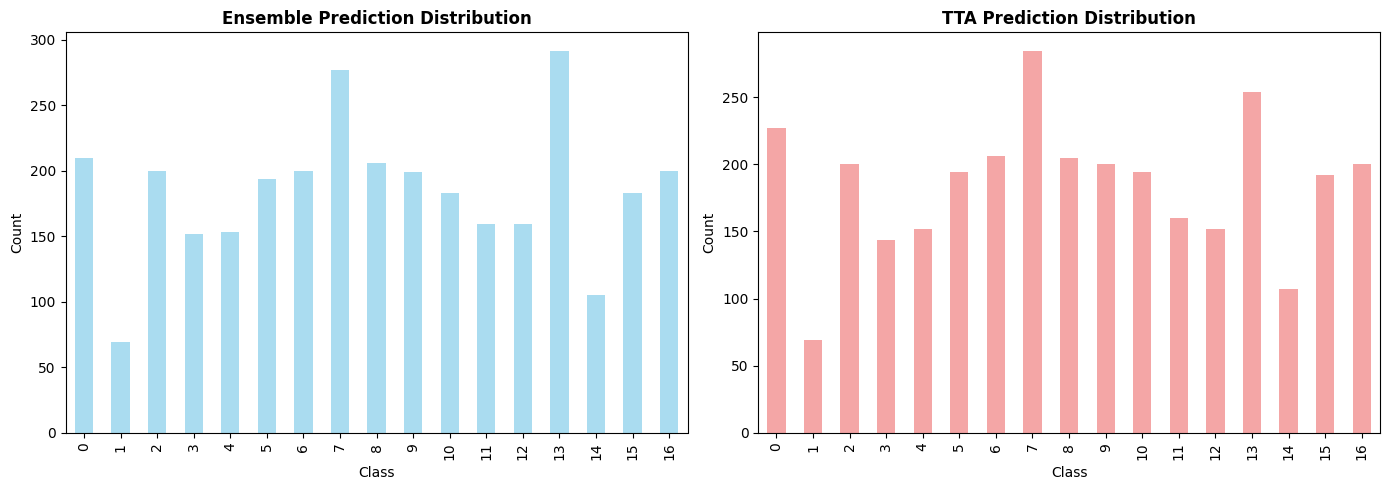

In [13]:
def compare_submissions(ensemble_csv, tta_csv):
    """
    Compare Ensemble vs TTA predictions
    """
    
    df_ensemble = pd.read_csv(ensemble_csv)
    df_tta = pd.read_csv(tta_csv)
    
    print("\n" + "=" * 60)
    print("Ensemble vs TTA Comparison")
    print("=" * 60)
    
    # Same predictions
    same_predictions = (df_ensemble['target'] == df_tta['target']).sum()
    total = len(df_ensemble)
    ratio = same_predictions / total * 100
    
    print(f"\nSame predictions: {same_predictions}/{total} ({ratio:.2f}%)")
    print(f"Different predictions: {total - same_predictions}/{total} ({100 - ratio:.2f}%)")
    
    # Different prediction analysis
    if total - same_predictions > 0:
        diff_mask = df_ensemble['target'] != df_tta['target']
        print(f"\nDifferent Prediction Analysis:")
        print(f"Ensemble preferred class: {df_ensemble.loc[diff_mask, 'target'].mode().values}")
        print(f"TTA preferred class: {df_tta.loc[diff_mask, 'target'].mode().values}")
    
    # Prediction distribution comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df_ensemble['target'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='skyblue', alpha=0.7
    )
    axes[0].set_title('Ensemble Prediction Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    
    df_tta['target'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='lightcoral', alpha=0.7
    )
    axes[1].set_title('TTA Prediction Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.savefig('ensemble_vs_tta_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# Run comparison (after TTA completes)
compare_submissions('submission_ENB6.csv', 'submission_tta.csv')